# ML Model Training - Bi-LSTM Support Ticket Priority
This notebook loads the REAL preprocessed data from Person 2 and trains the model.

In [23]:
!pip install tensorflow pandas scikit-learn matplotlib seaborn

In [24]:
# Colab Setup
import os
try:
    from google.colab import drive
    drive.mount("/content/drive")

    # Update paths for Colab
    base_dir = "/content/drive/MyDrive/Support-Ticket-Priority-Classifier/"
    os.chdir(base_dir)
    print("Running in Colab. Changing directory to", base_dir)
    DATA_DIR = os.path.join("backend/data/processed/")
    SAVE_DIR = os.path.join("backend/models/")

    print("Running in Colab. Models will be saved to Google Drive.")
except:
    DATA_DIR = "../backend/data/processed/"
    SAVE_DIR = "../backend/models/"
    print("Not running in Colab. Paths set for local execution.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab. Changing directory to /content/drive/MyDrive/Support-Ticket-Priority-Classifier/
Running in Colab. Models will be saved to Google Drive.


In [25]:
import os
import numpy as np
import pickle
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# --- Configuration ---
# Assuming running from the project root.

# Configuration from Person 2's HANDOFF_NOTES.txt
VOCAB_SIZE = 5968
MAX_SEQUENCE_LENGTH = 57
NUM_CLASSES = 4
# Ensure order matches LABEL_TO_ID: {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
CLASS_NAMES = ['Low', 'Medium', 'High', 'Critical']

# Hyperparameters
EMBEDDING_DIM = 64
LSTM_UNITS = 128

def load_data():
    """Loads preprocessed data and tokenizer from Person 2."""
    print("Loading data from", DATA_DIR)
    X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
    X_val   = np.load(os.path.join(DATA_DIR, 'X_val.npy'))
    X_test  = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
    y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
    y_val   = np.load(os.path.join(DATA_DIR, 'y_val.npy'))
    y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

    with open(os.path.join(DATA_DIR, 'tokenizer.pkl'), 'rb') as f:
        tokenizer = pickle.load(f)

    print(f"Loaded X_train shape: {X_train.shape}")
    print(f"Loaded y_train shape: {y_train.shape}")
    print(f"Vocab size: {len(tokenizer.word_index)}")

    return X_train, X_val, X_test, y_train, y_val, y_test, tokenizer


In [26]:
X_train, X_val, X_test, y_train, y_val, y_test, tokenizer = load_data()

Loading data from backend/data/processed/
Loaded X_train shape: (5877, 57)
Loaded y_train shape: (5877,)
Vocab size: 5967


In [27]:
X_train

array([[  5,  12,  10, ..., 174,   0,   0],
       [  5,  12,  10, ...,   0,   0,   0],
       [  5,  12,  10, ...,   0,   0,   0],
       ...,
       [  5,  54,   4, ...,  41, 137,   2],
       [  5,  12,  10, ..., 168,   0,   0],
       [  5,  12,  10, ...,   0,   0,   0]], dtype=int32)

In [28]:
y_train

array([3, 3, 2, ..., 1, 1, 0])

In [29]:
def get_class_weights(y_train):
    """Calculates class weights if there is an imbalance."""
    if len(y_train.shape) > 1 and y_train.shape[1] > 1:
        y_int = np.argmax(y_train, axis=1)
    else:
        y_int = y_train
    classes = np.unique(y_int)
    weights = compute_class_weight('balanced', classes=classes, y=y_int)
    class_weight_dict = dict(zip(classes, weights))
    print("Computed Class Weights:", class_weight_dict)
    return class_weight_dict

In [30]:
class_weight_dict = get_class_weights(y_train)
class_weight_dict

Computed Class Weights: {np.int64(0): np.float64(1.0224425887265136), np.int64(1): np.float64(0.9691622691292876), np.int64(2): np.float64(1.0146754143646408), np.int64(3): np.float64(0.9954268292682927)}


{np.int64(0): np.float64(1.0224425887265136),
 np.int64(1): np.float64(0.9691622691292876),
 np.int64(2): np.float64(1.0146754143646408),
 np.int64(3): np.float64(0.9954268292682927)}

In [31]:
def build_model(actual_vocab_size):
    """Builds the Bi-LSTM model architecture."""
    inputs = Input(shape=(MAX_SEQUENCE_LENGTH,), name='token_input')

    x = Embedding(
        input_dim=actual_vocab_size + 1,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=True,
        name='embedding'
    )(inputs)

    x = Bidirectional(
        LSTM(LSTM_UNITS, return_sequences=False, dropout=0.2, recurrent_dropout=0.1),
        name='bi_lstm'
    )(x)

    x = Dropout(0.4, name='dropout_1')(x)
    x = Dense(64, activation='relu', name='dense_1')(x)
    x = Dropout(0.3, name='dropout_2')(x)

    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy', # <--- CHANGE THIS LINE
    metrics=['accuracy']
    )

    return model
actual_vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index))
model = build_model(actual_vocab_size)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
class_weight_dict

{np.int64(0): np.float64(1.0224425887265136),
 np.int64(1): np.float64(0.9691622691292876),
 np.int64(2): np.float64(1.0146754143646408),
 np.int64(3): np.float64(0.9954268292682927)}

In [33]:
os.makedirs(SAVE_DIR, exist_ok=True)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=os.path.join(SAVE_DIR, 'ticket_classifier.keras'), monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.2586 - loss: 1.3879
Epoch 1: val_loss improved from None to 1.38607, saving model to backend/models/ticket_classifier.keras

Epoch 1: finished saving model to backend/models/ticket_classifier.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 61s 501ms/step - accuracy: 0.2530 - loss: 1.3880 - val_accuracy: 0.2518 - val_loss: 1.3861 - learning_rate: 0.0010
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.2550 - loss: 1.3860
Epoch 2: val_loss did not improve from 1.38607
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 433ms/step - accuracy: 0.2534 - loss: 1.3866 - val_accuracy: 0.2462 - val_loss: 1.3879 - learning_rate: 0.0010
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.2622 - loss: 1.3862
Epoch 3: val_loss did not improve from 1.38607
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 425ms/step - accuracy: 0.2603 - loss: 1.3859 - val_accuracy: 0.2415 - val_loss: 1.3873 - learning_rate: 0.0010
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 408

Saved training curves plot.


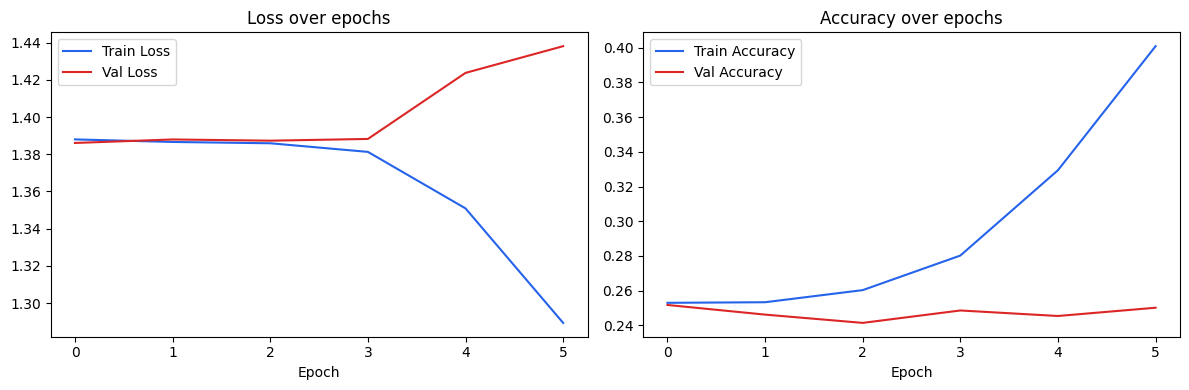

In [36]:
def plot_history(history):
    """Plots and saves the training history curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train Loss', color='#2563EB')
    ax1.plot(history.history['val_loss'], label='Val Loss', color='#DC2626')
    ax1.set_title('Loss over epochs')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Accuracy', color='#2563EB')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='#DC2626')
    ax2.set_title('Accuracy over epochs')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
    print("Saved training curves plot.")

plot_history(history)

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step

--- EVALUATION RESULTS ---
Test Accuracy:  0.2437
Macro F1-Score: 0.1803

Classification Report:
              precision    recall  f1-score   support

         Low       0.24      0.71      0.36       307
      Medium       0.26      0.14      0.18       325
        High       0.24      0.15      0.18       311
    Critical       0.00      0.00      0.00       317

    accuracy                           0.24      1260
   macro avg       0.19      0.25      0.18      1260
weighted avg       0.19      0.24      0.18      1260



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


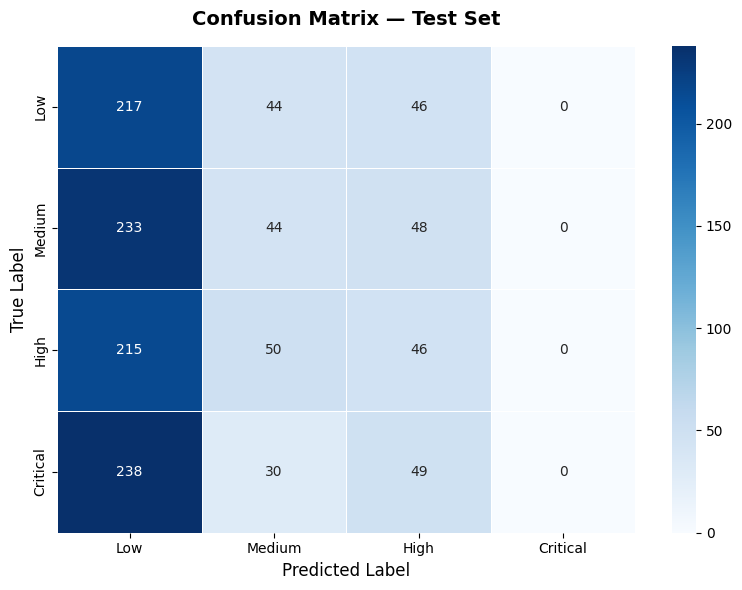

In [38]:
def evaluate_and_save(model, X_test, y_test):
    """Evaluates the model, prints metrics, saves confusion matrix and model."""
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = y_test

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n--- EVALUATION RESULTS ---")
    print(f"Test Accuracy:  {accuracy:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
    plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    #plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150)
    #print("Saved confusion matrix plot.")

    #model.save(os.path.join(SAVE_DIR, 'ticket_classifier.keras'))
    #print("✅ Final Model saved as ticket_classifier.keras")

evaluate_and_save(model, X_test, y_test)

In [ ]:
import os
import numpy as np
import pickle
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# --- Configuration ---
# Assuming running from the project root.

# Configuration from Person 2's HANDOFF_NOTES.txt
VOCAB_SIZE = 5968
MAX_SEQUENCE_LENGTH = 57
NUM_CLASSES = 4
# Ensure order matches LABEL_TO_ID: {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
CLASS_NAMES = ['Low', 'Medium', 'High', 'Critical']

# Hyperparameters
EMBEDDING_DIM = 64
LSTM_UNITS = 128

def load_data():
    """Loads preprocessed data and tokenizer from Person 2."""
    print("Loading data from", DATA_DIR)
    X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
    X_val   = np.load(os.path.join(DATA_DIR, 'X_val.npy'))
    X_test  = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
    y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
    y_val   = np.load(os.path.join(DATA_DIR, 'y_val.npy'))
    y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

    with open(os.path.join(DATA_DIR, 'tokenizer.pkl'), 'rb') as f:
        tokenizer = pickle.load(f)

    print(f"Loaded X_train shape: {X_train.shape}")
    print(f"Loaded y_train shape: {y_train.shape}")
    print(f"Vocab size: {len(tokenizer.word_index)}")

    return X_train, X_val, X_test, y_train, y_val, y_test, tokenizer

def get_class_weights(y_train):
    """Calculates class weights if there is an imbalance."""
    y_int = np.argmax(y_train, axis=1)
    classes = np.unique(y_int)
    weights = compute_class_weight('balanced', classes=classes, y=y_int)
    class_weight_dict = dict(zip(classes, weights))
    print("Computed Class Weights:", class_weight_dict)
    return class_weight_dict

def build_model(actual_vocab_size):
    """Builds the Bi-LSTM model architecture."""
    inputs = Input(shape=(MAX_SEQUENCE_LENGTH,), name='token_input')

    x = Embedding(
        input_dim=actual_vocab_size + 1,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=True,
        name='embedding'
    )(inputs)

    x = Bidirectional(
        LSTM(LSTM_UNITS, return_sequences=False, dropout=0.2, recurrent_dropout=0.1),
        name='bi_lstm'
    )(x)

    x = Dropout(0.4, name='dropout_1')(x)
    x = Dense(64, activation='relu', name='dense_1')(x)
    x = Dropout(0.3, name='dropout_2')(x)

    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def train_model(model, X_train, y_train, X_val, y_val, class_weight_dict):
    """Trains the model with callbacks."""
    os.makedirs(SAVE_DIR, exist_ok=True)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=os.path.join(SAVE_DIR, 'ticket_classifier.keras'), monitor='val_loss', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=64,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    return history

def plot_history(history):
    """Plots and saves the training history curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train Loss', color='#2563EB')
    ax1.plot(history.history['val_loss'], label='Val Loss', color='#DC2626')
    ax1.set_title('Loss over epochs')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Accuracy', color='#2563EB')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='#DC2626')
    ax2.set_title('Accuracy over epochs')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
    print("Saved training curves plot.")

def evaluate_and_save(model, X_test, y_test):
    """Evaluates the model, prints metrics, saves confusion matrix and model."""
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n--- EVALUATION RESULTS ---")
    print(f"Test Accuracy:  {accuracy:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
    plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150)
    print("Saved confusion matrix plot.")

    model.save(os.path.join(SAVE_DIR, 'ticket_classifier.keras'))
    print("✅ Final Model saved as ticket_classifier.keras")

if __name__ == "__main__":
    # 1. Load the real data
    X_train, X_val, X_test, y_train, y_val, y_test, tokenizer = load_data()

    # 2. Handle class weights
    class_weights = get_class_weights(y_train)

    # 3. Build Model
    actual_vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index))
    model = build_model(actual_vocab_size)
    model.summary()

    # 4. Train Model
    history = train_model(model, X_train, y_train, X_val, y_val, class_weights)

    # 5. Evaluate and Plot
    plot_history(history)
    evaluate_and_save(model, X_test, y_test)
    print("\n🎉 ML Pipeline Complete!")


Loading data from /content/drive/MyDrive/Support-Ticket-Priority-Classifier/backend/data/processed/
Loaded X_train shape: (5877, 57)
Loaded y_train shape: (5877,)
Vocab size: 5967


AxisError: axis 1 is out of bounds for array of dimension 1

## Option 1: Run Hyperparameter Tuning via Module Import
If you want to keep your notebook clean, you can import and run the tuning pipeline directly from the `scripts/tune_classifier.py` file.

In [2]:
import os
os.path.abspath('..')

'/'

In [3]:
os.chdir('/content/drive/MyDrive/Support-Ticket-Priority-Classifier')

In [4]:
os.getcwd()

'/content/drive/MyDrive/Support-Ticket-Priority-Classifier'

Trial 10 Complete [00h 16m 16s]
val_accuracy: 0.2591036558151245

Best val_accuracy So Far: 0.2759103775024414
Total elapsed time: 01h 12m 33s

--- Running 5-Fold Stratified Cross Validation with best parameters ---

Training Fold 1...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 1 - Accuracy: 0.2416, Macro F1: 0.2336

Training Fold 2...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 2 - Accuracy: 0.2418, Macro F1: 0.2314

Training Fold 3...


...

Fold 4 - Accuracy: 0.2467, Macro F1: 0.2334

Training Fold 5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Fold 5 - Accuracy: 0.2705, Macro F1: 0.2311

--- Cross Validation Results ---
Average CV Accuracy:  0.2515 (+/- 0.0110)
Average CV Macro F1:  0.2346 (+/- 0.0046)

--- Training Final Model on Full CV Set ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.2529 - loss: 1.3889 - val_accuracy: 0.2591 - val_loss: 1.3874 - learning_rate: 1.0000e-04
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.2554 - loss: 1.3893 - val_accuracy: 0.2367 - val_loss: 1.3870 - learning_rate: 1.0000e-04
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.2498 - loss: 1.3892 - val_accuracy: 0.2353 - val_loss: 1.3870 - learning_rate: 1.0000e-04
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.2625 - loss: 1.3866 - val_accuracy: 0.2283 - val_loss: 1.3871 - learning_rate: 1.0000e-04
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2568 - loss: 1.3866
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
101/101 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.2618 - loss: 1.3863 - val_accuracy: 0.2353 - val_loss: 1.3876 - learning_rate: 1.0000e-04
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 

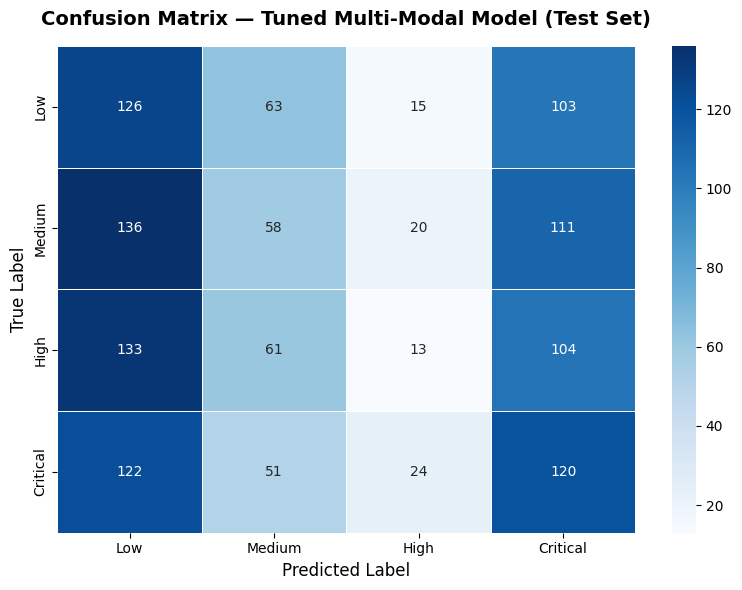

In [5]:
import sys
import os

# Add the project root directory to the python path so we can import the scripts folder
sys.path.append(os.path.abspath('..'))

from scripts.tune_classifier import load_data, tune_hyperparameters, run_cross_validation, train_final_model_and_evaluate

# 1. Load Data
X_cv_text, X_cv_tab, y_cv, X_test_text, X_test_tab, y_test, tokenizer = load_data()
actual_vocab_size = min(5968, len(tokenizer.word_index))
tabular_dim = X_cv_tab.shape[1]

# 2. Run Hyperparameter Tuning
tuner, best_hps = tune_hyperparameters(X_cv_text, X_cv_tab, y_cv, actual_vocab_size, tabular_dim)

# 3. Validate with Stratified K-Fold
run_cross_validation(best_hps, X_cv_text, X_cv_tab, y_cv, actual_vocab_size, tabular_dim, n_splits=5)

# 4. Train final model and evaluate
train_final_model_and_evaluate(best_hps, X_cv_text, X_cv_tab, y_cv, X_test_text, X_test_tab, y_test, actual_vocab_size, tabular_dim)


---
## Option 2: Run Hyperparameter Tuning with Explicit Functions
If you prefer to see and modify the tuning logic directly inside the notebook, run the cells below instead.

In [ ]:
import os
import numpy as np
import pickle
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import keras_tuner as kt

# --- Configuration ---
DATA_DIR = '../backend/data/processed/'
SAVE_DIR = '../backend/models/'

VOCAB_SIZE = 5968
MAX_SEQUENCE_LENGTH = 57
NUM_CLASSES = 4
CLASS_NAMES = ['Low', 'Medium', 'High', 'Critical']

def load_data_tuning():
    X_train_text = np.load(os.path.join(DATA_DIR, 'X_train_text.npy'))
    X_val_text   = np.load(os.path.join(DATA_DIR, 'X_val_text.npy'))
    X_test_text  = np.load(os.path.join(DATA_DIR, 'X_test_text.npy'))

    X_train_tab = np.load(os.path.join(DATA_DIR, 'X_train_tabular.npy'))
    X_val_tab   = np.load(os.path.join(DATA_DIR, 'X_val_tabular.npy'))
    X_test_tab  = np.load(os.path.join(DATA_DIR, 'X_test_tabular.npy'))

    y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
    y_val   = np.load(os.path.join(DATA_DIR, 'y_val.npy'))
    y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

    with open(os.path.join(DATA_DIR, 'tokenizer.pkl'), 'rb') as f:
        tokenizer = pickle.load(f)

    X_cv_text = np.concatenate([X_train_text, X_val_text], axis=0)
    X_cv_tab = np.concatenate([X_train_tab, X_val_tab], axis=0)

    y_train_int = np.argmax(y_train, axis=1) if len(y_train.shape) > 1 and y_train.shape[1] > 1 else y_train
    y_val_int = np.argmax(y_val, axis=1) if len(y_val.shape) > 1 and y_val.shape[1] > 1 else y_val
    y_test_int = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 and y_test.shape[1] > 1 else y_test

    y_cv = np.concatenate([y_train_int, y_val_int], axis=0)
    return X_cv_text, X_cv_tab, y_cv, X_test_text, X_test_tab, y_test_int, tokenizer

def build_model_tuner(hp, actual_vocab_size, tabular_dim):
    hp_embedding_dim = hp.Choice('embedding_dim', values=[32, 64, 128])
    hp_lstm_units = hp.Choice('lstm_units', values=[64, 128, 256])
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.2, max_value=0.6, step=0.1)
    hp_dense_tab = hp.Choice('dense_tab', values=[32, 64])
    hp_dropout_tab = hp.Float('dropout_tab', min_value=0.1, max_value=0.5, step=0.1)
    hp_dense_merged = hp.Choice('dense_merged', values=[32, 64, 128])
    hp_dropout_merged = hp.Float('dropout_merged', min_value=0.2, max_value=0.6, step=0.1)
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    # Text Pathway
    text_input = Input(shape=(MAX_SEQUENCE_LENGTH,), name='text_input')
    x_text = Embedding(input_dim=actual_vocab_size + 1, output_dim=hp_embedding_dim, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True)(text_input)
    x_text = Bidirectional(LSTM(hp_lstm_units, return_sequences=False, dropout=0.2, recurrent_dropout=0.1))(x_text)
    x_text = Dropout(hp_dropout_1)(x_text)

    # Tabular Pathway
    tabular_input = Input(shape=(tabular_dim,), name='tabular_input')
    x_tab = Dense(hp_dense_tab, activation='relu')(tabular_input)
    x_tab = Dropout(hp_dropout_tab)(x_tab)

    # Merged
    merged = Concatenate()([x_text, x_tab])
    x_merged = Dense(hp_dense_merged, activation='relu')(merged)
    x_merged = Dropout(hp_dropout_merged)(x_merged)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x_merged)

    model = Model(inputs=[text_input, tabular_input], outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

X_cv_text, X_cv_tab, y_cv, X_test_text, X_test_tab, y_test_int, tokenizer = load_data_tuning()
actual_vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index))
tabular_dim = X_cv_tab.shape[1]

tuner = kt.RandomSearch(
    hypermodel=lambda hp: build_model_tuner(hp, actual_vocab_size, tabular_dim),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='../backend/tuning_logs',
    project_name='ticket_classifier_tuning_notebook_mm',
    overwrite=False
)

classes = np.unique(y_cv)
class_weights = dict(zip(classes, compute_class_weight('balanced', classes=classes, y=y_cv)))

print("\nStarting hyperparameter search...")
tuner.search(
    [X_cv_text, X_cv_tab], y_cv, epochs=15, validation_split=0.2,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    batch_size=64, verbose=1
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Optimal config: Embedding {best_hps.get('embedding_dim')}, LSTM {best_hps.get('lstm_units')}, LR {best_hps.get('learning_rate')}")
